In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import(
    confusion_matrix,
    f1_score,
    recall_score,
    accuracy_score,
    precision_score
)
from sklearn.model_selection import train_test_split

In [7]:
df = pd.read_csv('../Dataset/pima_diabetes.csv')

In [8]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


<Axes: >

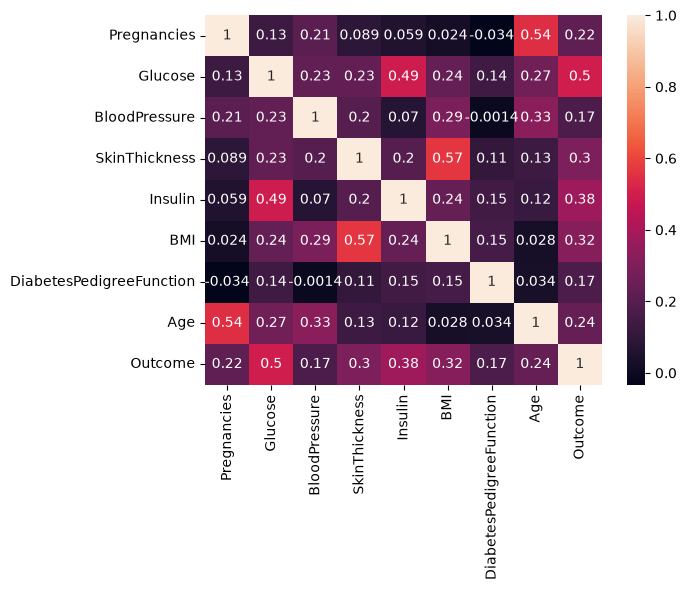

In [11]:
corr = df.corr(numeric_only = True)
sns.heatmap(
    data = corr,
    annot= True,
)

In [17]:
df['Insulin'].unique()

array([169.5, 102.5,  94. , 168. ,  88. , 543. , 846. , 175. , 230. ,
        83. ,  96. , 235. , 146. , 115. , 140. , 110. , 245. ,  54. ,
       192. , 207. ,  70. , 240. ,  82. ,  36. ,  23. , 300. , 342. ,
       304. , 142. , 128. ,  38. , 100. ,  90. , 270. ,  71. , 125. ,
       176. ,  48. ,  64. , 228. ,  76. , 220. ,  40. , 152. ,  18. ,
       135. , 495. ,  37. ,  51. ,  99. , 145. , 225. ,  49. ,  50. ,
        92. , 325. ,  63. , 284. , 119. , 204. , 155. , 485. ,  53. ,
       114. , 105. , 285. , 156. ,  78. , 130. ,  55. ,  58. , 160. ,
       210. , 318. ,  44. , 190. , 280. ,  87. , 271. , 129. , 120. ,
       478. ,  56. ,  32. , 744. , 370. ,  45. , 194. , 680. , 402. ,
       258. , 375. , 150. ,  67. ,  57. , 116. , 278. , 122. , 545. ,
        75. ,  74. , 182. , 360. , 215. , 184. ,  42. , 132. , 148. ,
       180. , 205. ,  85. , 231. ,  29. ,  68. ,  52. , 255. , 171. ,
        73. , 108. ,  43. , 167. , 249. , 293. ,  66. , 465. ,  89. ,
       158. ,  84. ,

In [20]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [21]:
df.groupby('Outcome')['Pregnancies'].describe()

,count,mean,std,min,25%,50%,75%,max
Outcome,,,,,,,,
0,500.0,3.298000,3.017185,0.0,1.00,2.0,5.0,13.0
1,268.0,4.865672,3.741239,0.0,1.75,4.0,8.0,17.0


In [22]:
from scipy.stats import pointbiserialr

r, p = pointbiserialr(df['Pregnancies'], df['Outcome'])

print("Correlation:", r)
print("p-value:", p)

Correlation: 0.22189815303398686
p-value: 5.065127298053726e-10


In [26]:
r, p = pointbiserialr(df['Outcome'],df['Glucose'])
print("Correlation:", r)
print("p-value:", p)

Correlation: 0.4959904766023165
p-value: 6.2269331337020935e-49


In [27]:
from scipy.stats import ttest_ind

group0 = df.loc[df['Outcome'] == 0, 'Glucose']
group1 = df.loc[df['Outcome'] == 1, 'Glucose']

t_stat, p_value = ttest_ind(group0, group1, equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: -14.992112521284485
p-value: 8.301766379086793e-42


In [30]:
model = LogisticRegression()
x = df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']]
y = df['Outcome']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = .2)
model.fit(x_train,y_train)

C:\Users\aroma\Desktop\Spectrum\steps\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [34]:
cm = confusion_matrix(y_test,y_pred)
cm

array([[88, 17],
       [22, 27]])

In [39]:
y_pred = model.predict(x_test)

In [43]:
temp = zip(y_test,y_pred)
tp,tn,fp,fn = 0,0,0,0
for actual,predict in temp:
    if actual == 1:
        if predict == 1:
            tp += 1
        elif predict == 0:
            fn += 1
    elif actual == 0:
        if predict == 1:
            fp +=1 
        elif predict == 0:
            tn += 1
cm = np.array([[tn,fp],[fn,tp]])
cm

array([[88, 17],
       [22, 27]])

In [44]:
accuracy = (tp+tn) / (tp+tn+fp+fn)
accuracy

0.7467532467532467

In [46]:
accuracy = accuracy_score(y_test,y_pred)
accuracy

0.7467532467532467

In [48]:
precision = tp/(tp+fp)
precision

0.6136363636363636

In [50]:
precision = precision_score(y_test,y_pred)
precision

0.6136363636363636

In [51]:
recall = tp / (tp+ fn)
recall

0.5510204081632653

In [53]:
recall = recall_score(y_test,y_pred)
recall

0.5510204081632653

In [54]:
f1 = 2*(precision * recall) / (precision + recall)
f1

0.5806451612903225

In [56]:
f1 = f1_score(y_test,y_pred)
f1

0.5806451612903226